In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from pathlib import Path
import torch
from transformers import AutoTokenizer
from torch.utils.data import DataLoader
from torch import nn
from torch.functional import F
from tqdm import tqdm
from transformers import DataCollatorForSeq2Seq
from torch.utils.data import DataLoader
from datasets import Dataset
import numpy as np
from sklearn.model_selection import train_test_split

from src.data_utils import get_sample_from_row_original, filter_irrelevant, prune_frequent_samples
from src.inference_utils import predict
from src.metrics import lemmatization_accuracy
from src.custom_models.prunable_bart import PrunableBartForConditionalGeneration

In [2]:
CURDIR = Path.cwd()

DATADIR = CURDIR / "data" / "original"
assert DATADIR.exists()

MODELS_DIR = CURDIR / "models"
assert MODELS_DIR.exists()

TEACHER_ID = MODELS_DIR / 'baseline'
assert TEACHER_ID.exists()

# STUDENT_ID = MODELS_DIR / "checkpoint_120226"
# assert STUDENT_ID.exists()

# RESULT_MODEL_DIR = MODELS_DIR / "checkpoint_120226_2"
# if not RESULT_MODEL_DIR.exists():
#     RESULT_MODEL_DIR.mkdir()
# RESULT_MODEL_PATH = RESULT_MODEL_DIR / "model.pt"

MAX_LENGTH = 512
DEVICE = "cuda"

In [3]:
df_train = pd.read_csv(DATADIR / "train.csv", index_col=0, sep="\t")
df_train["sample"] = df_train.apply(lambda row: get_sample_from_row_original(row)[0], axis=1)
df_train = filter_irrelevant(df_train)
df_train = prune_frequent_samples(df_train)  # здесь подрезаем несбалансированное начальное распределение
print(f"Original dataset size: {len(df_train)}")

_, df_calibrate = train_test_split(
    df_train,
    test_size=0.05,
    random_state=42,
    shuffle=True
)
print(f"Train set size: {len(df_train)} ({len(df_train)/len(df_train)*100:.1f}%)")
print(f"Calibration set size: {len(df_calibrate)} ({len(df_calibrate)/len(df_train)*100:.1f}%)")

df_dev = pd.read_csv(DATADIR / "dev.csv", index_col=0, sep="\t")
df_dev["sample"] = df_dev.apply(lambda row: get_sample_from_row_original(row)[0], axis=1)
df_dev = filter_irrelevant(df_dev)
df_dev = df_dev.drop_duplicates(subset=["sample"])  # отсюда просто удаляем все дубли чтобы честно мериться
print(f"Original dev size: {len(df_dev)}")

Original dataset size: 958668
Train set size: 958668 (100.0%)
Calibration set size: 47934 (5.0%)
Original dev size: 52827


In [4]:
tokenizer = AutoTokenizer.from_pretrained(TEACHER_ID)
model = PrunableBartForConditionalGeneration.from_pretrained(TEACHER_ID).to("cuda")

model.eval()
for param in model.parameters():
    param.requires_grad = False

In [5]:
df_train = df_train[["sample", "lemma"]]
df_calibrate = df_calibrate[["sample", "lemma"]]
df_dev = df_dev[["sample", "lemma"]]

In [6]:
# train = Dataset.from_pandas(
#     df_train[["sample", "lemma"]],
# ).rename_columns({
#     "sample": "source",
#     "lemma": "target",
# }).shuffle(seed=42)

calibrate = Dataset.from_pandas(
    df_calibrate[["sample", "lemma"]],
).rename_columns({
    "sample": "source",
    "lemma": "target",
}).shuffle(seed=42)

In [7]:
def tokenize_function(examples,):

    model_inputs = tokenizer(
        examples["source"],
        max_length=70,
        truncation=True,
        padding=False,
    )

    labels = tokenizer(
        examples["target"],
        max_length=70,
        truncation=True,
        padding=False,
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

In [8]:
# tokenized_train = train.map(
#     tokenize_function,
#     batched=True,
#     batch_size=1000,
#     remove_columns=train.column_names,
# )

tokenized_calibration = calibrate.map(
    tokenize_function,
    batched=True,
    batch_size=1000,
    remove_columns=calibrate.column_names,
)

Map: 100%|██████████| 47934/47934 [00:04<00:00, 11259.17 examples/s]


In [9]:
tokenized_calibration

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 47934
})

In [10]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    padding=True,
    return_tensors="pt",
    label_pad_token_id=-100,
)

In [11]:
BATCH_SIZE = 56  # 56? 48

In [12]:
# train_dataloader = DataLoader(
#     tokenized_train,
#     batch_size=BATCH_SIZE,
#     shuffle=True,
#     collate_fn=data_collator,
#     num_workers=1,
#     pin_memory=True,
#     drop_last=False,
# )

In [13]:
calibrate_dataloader = DataLoader(
    tokenized_calibration,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=data_collator,
    num_workers=1,
    pin_memory=True,
    drop_last=False,
)

In [14]:
def print_cfg(model):
    print("Model configuration:")
    print(f"Encoder layers: {model.config.encoder_layers}")
    print(f"Decoder layers: {model.config.decoder_layers}")
    print(f"Encoder attention heads: {model.config.encoder_attention_heads}")
    print(f"Decoder attention heads: {model.config.decoder_attention_heads}")
    print(f"Hidden size: {model.config.d_model}")
    print(f"FFN dimension: {model.config.encoder_ffn_dim} / {model.config.decoder_ffn_dim}")
    print(f"Total parameters: {model.num_parameters():,}")

In [15]:
print_cfg(model)

Model configuration:
Encoder layers: 6
Decoder layers: 6
Encoder attention heads: 12
Decoder attention heads: 12
Hidden size: 768
FFN dimension: 3072 / 3072
Total parameters: 139,420,416


In [16]:
from collections import defaultdict

In [ ]:
class BARTImportanceEstimator:
    def __init__(
        self,
        model,
        dataloader,
        device="cuda",
    ):
        self.model = model
        self.dataloader = dataloader
        self.device = device

        self.encoder_self_attention_heads = defaultdict(list)
        self.decoder_self_attention_heads = defaultdict(list)
        self.decoder_cross_attention_heads = defaultdict(list)

        self.hooks = []

    def _attn_hook(self, id_, container):
        def hook(module, input, output):
            attn_weights = output[1]
            head_norms = torch.norm(attn_weights, p=2, dim=-1)
            seq_aggregated = torch.mean(head_norms, dim=-1)
            batch_aggregated = torch.norm(seq_aggregated, p=2, dim=0)
            container[id_].append(
                batch_aggregated.detach().cpu()
            )
        return hook

    def _register_encoder_self_attn_hooks(self,):
        for i, layer in enumerate(self.model.model.encoder.layers):
            cur_hook = self._attn_hook(i, self.encoder_self_attention_heads)
            reg_hook = layer.self_attn.register_forward_hook(cur_hook)
            self.hooks.append(reg_hook)

    def _register_decoder_self_attn_hooks(self):
        for i, layer in enumerate(self.model.model.decoder.layers):
            cur_hook = self._attn_hook(i, self.decoder_self_attention_heads)
            reg_hook = layer.self_attn.register_forward_hook(cur_hook)
            self.hooks.append(reg_hook)

    def _register_decoder_cross_attn_hooks(self):
        for i, layer in enumerate(self.model.model.decoder.layers):
            if hasattr(layer, 'encoder_attn'):
                cur_hook = self._attn_hook(i, self.decoder_cross_attention_heads)
                reg_hook = layer.encoder_attn.register_forward_hook(cur_hook)
                self.hooks.append(reg_hook)

    def _register_hooks(self):
        self._register_encoder_self_attn_hooks()
        self._register_decoder_self_attn_hooks()
        self._register_decoder_cross_attn_hooks()

    def _remove_hooks(self):
        for hook in self.hooks:
            hook.remove()

    def _aggregate_all_stuff(self):
        for batch in tqdm(self.dataloader, desc="Батчи потекли"):
            input_ids = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            labels = batch["labels"].to(self.device)
            decoder_input_ids = model.prepare_decoder_input_ids_from_labels(labels)

            # здесь собирать ничего не нужно, хуки это сделают
            with torch.no_grad():
                _ = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    decoder_input_ids=decoder_input_ids,
                    labels=labels,
                    output_attentions=True,
                )

    def _aggregate(self, key, data_dict, importance_scores):
        for id_, activations in data_dict.items():
            stacked = torch.stack(activations)
            importance_scores[f'{key}_{id_}'] = stacked.mean(dim=0)


    def compute_importance(self):

        self._register_hooks()

        self._aggregate_all_stuff()

        self._remove_hooks()

        importance_scores = dict()

        self._aggregate('encoder_selfheads', self.encoder_self_attention_heads, importance_scores)
        self._aggregate('decoder_self_heads', self.decoder_self_attention_heads, importance_scores)
        self._aggregate('decoder_cross_heads', self.decoder_cross_attention_heads, importance_scores)

        return importance_scores


In [18]:
estimator = BARTImportanceEstimator(
    model=model,
    dataloader=calibrate_dataloader,
    device="cuda"
)

importance_scores = estimator.compute_importance()


Батчи потекли: 100%|██████████| 856/856 [01:09<00:00, 12.30it/s]


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [22]:
attn_types = [
    ('encoder_selfheads', 'Encoder Self-Attention'),
    ('decoder_self_heads', 'Decoder Self-Attention'), 
    ('decoder_cross_heads', 'Decoder Cross-Attention')
]

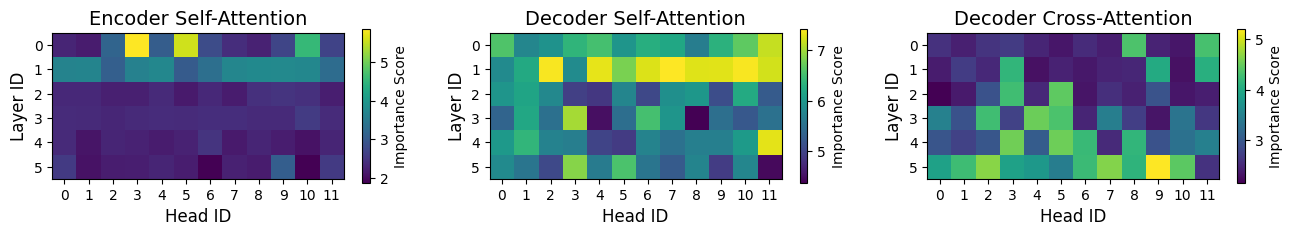

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 2))

for id_, (prefix, title) in enumerate(attn_types):

    layer_scores = []
    layer_indices = []

    for key in sorted(importance_scores.keys()):
        if prefix in key:
            layer_scores.append(importance_scores[key].numpy())
            layer_indices.append(int(key.split('_')[-1]))
    
    if layer_scores:
        scores_array = np.array(layer_scores)

        im = axes[id_].imshow(scores_array,)

        axes[id_].set_xlabel('Head ID', fontsize=12)
        axes[id_].set_ylabel('Layer ID', fontsize=12)
        axes[id_].set_title(title, fontsize=14)

        axes[id_].set_xticks(range(scores_array.shape[1]))
        axes[id_].set_yticks(range(len(layer_indices)))
        axes[id_].set_yticklabels(layer_indices)

        plt.colorbar(im, ax=axes[id_], label='Importance Score')

# plt.tight_layout()

plt.show()

In [122]:
def define_which_to_prune(arr: torch.Tensor, thr: float):

    prune_mask = arr < thr

    if all(prune_mask):
        return define_which_to_prune(arr, thr=arr.max())

    to_prune = torch.where(prune_mask)[0].tolist()

    return to_prune

In [123]:
# это не лучшее что я делал но я уже не могу :(

heads_to_prune = {
    "encoder_self_heads": {},
    "decoder_self_heads": {},
    "decoder_cross_heads": {},
}

for k, arr in importance_scores.items():

    if "encoder" in k:
        thr = 3.5
    elif "self" in k:
        thr = 5.5
    elif "cross" in k:
        thr = 3.5
    else:
        raise ValueError

    to_prune = define_which_to_prune(arr, thr=thr)

    id_ = int(k.split("_")[-1])

    if "encoder" in k:
        heads_to_prune["encoder_self_heads"][id_] = to_prune
    elif "self" in k:
        heads_to_prune["decoder_self_heads"][id_] = to_prune
    elif "cross" in k:
        heads_to_prune["decoder_cross_heads"][id_] = to_prune

In [124]:
heads_to_prune

{'encoder_self_heads': {0: [0, 1, 2, 4, 6, 7, 8, 9, 11],
  1: [2, 5, 6, 11],
  2: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11],
  3: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11],
  4: [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11],
  5: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11]},
 'decoder_self_heads': {0: [],
  1: [],
  2: [3, 4, 6, 9, 11],
  3: [0, 2, 4, 5, 8, 9, 10],
  4: [4, 5],
  5: [2, 7, 9, 11]},
 'decoder_cross_heads': {0: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10],
  1: [0, 1, 2, 4, 5, 6, 7, 8, 10],
  2: [0, 1, 2, 4, 6, 7, 8, 9, 10, 11],
  3: [0, 1, 3, 6, 7, 8, 9, 10, 11],
  4: [0, 1, 2, 4, 7, 9, 10, 11],
  5: [5, 11]}}

In [125]:
heads_to_prune = {'encoder_self_heads': {0: [0, 1, 2, 4, 6, 7, 8, 9, 11],
  1: [2, 5, 6, 11],
  2: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11],
  3: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11],
  4: [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11],
  5: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11]},
 'decoder_self_heads': {0: [],
  1: [],
  2: [3, 4, 6, 9, 11],
  3: [0, 2, 4, 5, 8, 9, 10],
  4: [4, 5],
  5: [2, 7, 9, 11]},
 'decoder_cross_heads': {0: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10],
  1: [0, 1, 2, 4, 5, 6, 7, 8, 10],
  2: [0, 1, 2, 4, 6, 7, 8, 9, 10, 11],
  3: [0, 1, 3, 6, 7, 8, 9, 10, 11],
  4: [0, 1, 2, 4, 7, 9, 10, 11],
  5: [5, 11]}}

In [126]:
model.prune_heads(heads_to_prune)

In [128]:
print_cfg(model)  # * attention heads теперь врет, а вот кол-во параметров видно нормально

Model configuration:
Encoder layers: 6
Decoder layers: 6
Encoder attention heads: 12
Decoder attention heads: 12
Hidden size: 768
FFN dimension: 3072 / 3072
Total parameters: 115,214,016


In [129]:
df_test = pd.read_csv(DATADIR / "test.csv", index_col=0, sep="\t")
df_test.head()

,form,pos,feats,lemma,freq_rank,subset,filename,split
0,Ещё,ADV,Degree:Pos,еще,45,rubic_data-master,ru_taiga-ud-test.conllu,holdout
1,зимой,NOUN,Animacy:Inan Case:Ins Gender:Fem Number:Sing,зима,1147,rubic_data-master,ru_taiga-ud-test.conllu,holdout
2,в,ADP,NaN,в,2,rubic_data-master,ru_taiga-ud-test.conllu,holdout
3,армиях,NOUN,Animacy:Inan Case:Loc Gender:Fem Number:Plur,армия,602,rubic_data-master,ru_taiga-ud-test.conllu,holdout
4,ДНР,PROPN,Abbr:Yes NameType:Geo,ДНР,other,rubic_data-master,ru_taiga-ud-test.conllu,holdout


In [131]:
df_unknown = df_test[df_test["split"] == "unknown"]
df_holdout = df_test[df_test["split"] == "holdout"]

df_test.shape[0], df_holdout.shape[0], df_unknown.shape[0]

(153991, 138882, 15109)

In [132]:
from src.metrics import preds_time_tps_lacc

In [133]:
p = lambda texts: predict(texts, model, tokenizer, "cuda", )

In [134]:
_, elapsed_time, tps, lacc = preds_time_tps_lacc(p, df_test.head(30000))
print(f"Elapsed time: {elapsed_time:.3f} seconds")
print(f"TPS: {tps:.3f}")
print(f"lAcc: {lacc:.3f}")
print()

_, elapsed_time, tps, lacc = preds_time_tps_lacc(p, df_holdout.head(30000))
print(f"Elapsed time: {elapsed_time:.3f} seconds")
print(f"TPS: {tps:.3f}")
print(f"lAcc: {lacc:.3f}")
print()

_, elapsed_time, tps, lacc = preds_time_tps_lacc(p, df_unknown)
print(f"Elapsed time: {elapsed_time:.3f} seconds")
print(f"TPS: {tps:.3f}")
print(f"lAcc: {lacc:.3f}")
print()

938it [01:02, 15.07it/s]                         


Elapsed time: 62.253 seconds
TPS: 481.907
lAcc: 0.380



938it [01:05, 14.33it/s]                         


Elapsed time: 65.449 seconds
TPS: 458.370
lAcc: 0.440



473it [00:35, 13.50it/s]                         

Elapsed time: 35.041 seconds
TPS: 431.180
lAcc: 0.036



In [135]:
MODEL_DIR_NAME = "pruned_heads_l2_mean_l2_35_55_35"

In [138]:
torch.save(model, MODELS_DIR / MODEL_DIR_NAME / "model.pt")

In [ ]:
tokenizer.save_pretrained( MODELS_DIR / MODEL_DIR_NAME)

In [ ]:
samples = df_dev["sample"].tail(10).tolist()
samples

In [149]:
predict(
    samples, model, tokenizer, "cuda"
)

1it [00:00, 16.31it/s]


['гова', 'болет', 'к', 'ук', 'счет', 'рега', 'прить', 'прий', 'страж', 'сесто']

In [151]:
loaded_model = torch.load(MODELS_DIR / MODEL_DIR_NAME / "model.pt", weights_only=False)

In [152]:
predict(
    samples, loaded_model, tokenizer, "cuda"
)

1it [00:00, 17.42it/s]


['гова', 'болет', 'к', 'ук', 'счет', 'рега', 'прить', 'прий', 'страж', 'сесто']